# BoC Rate Cuts — Probability Prediction Experiment

This notebook runs the full predictor lineup on the discrete BoC task:
**P(rate cut at the next fixed announcement date)**, scored with the Brier
score. Read `01_boc_data_exploration.ipynb` first for the problem framing,
data layer, and cutoff-discipline walkthrough.

**The leakage problem, binary edition.** Frontier LLMs were trained on data
that includes news coverage of every historical BoC decision. For backtest
origins in 2010–2024, an LLM-based predictor may simply *remember* what the
Bank decided — and unlike the continuous use cases, here memorisation is
worth even more, because a single recalled bit (cut / no cut) is the entire
answer. Backtest Brier scores for LLMP and the agent are therefore **upper
bounds on live skill**, useful for verifying the pipeline and calibration
format, not for claiming forecasting ability. The conventional predictors
(base rate, logistic regression) are blind to the future by construction, so
their backtest scores are honest.

The protected 2025–2026 eval window at the end is closer to (and partly
beyond) current model training cutoffs — that comparison is fairer, and the
budget-gated `evaluate()` harness keeps it honest.

**What's here:**

1. Setup and experiment config — smoke (3 origins) vs full (120 origins).
2. Spec — loaded from YAML; explicit `origin_dates` for the meeting calendar.
3. Predictors — base rate, logistic regression, binary LLMP, agentic analyst.
4. Backtest — cached on disk; Brier leaderboard with skill scores.
5. Decision timeline and reliability (calibration) curve.
6. Inspecting agent reasoning — the seam for reasoning-alignment evaluation.
7. Protected eval — budget-gated 2025–2026 window.

---
## 1. Setup

The analytical code lives in modules alongside this notebook:

- `data.py` — registers the target rate, derived event series, and covariates.
- `predictors/` — logistic baseline and the BoC binary-LLMP recipe.
- `analyst_agent/` — the agentic BoC analyst (prompt builder + configs).
- `analysis.py` / `plots.py` — Brier leaderboard, calibration, timeline.

Specs (all under `implementations/boc_rate_decisions/specs/`):

| Spec file | Origins | Window | Notes |
|---|---|---|---|
| `boc_rate_cut_smoke.yaml` | 3 | 2024 | One hold + two cuts; fast dev loop |
| `boc_rate_cut_backtest.yaml` | 120 | 2010–2024 | Full backtest across three easing cycles |
| `boc_rate_cut_eval.yaml` | 12 | 2025–Jun 2026 | Protected, `max_runs: 5` |

Populate the data cache once before running:

```bash
uv run python scripts/fetch_boc.py
```

In [1]:
from __future__ import annotations

import warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yaml
from dotenv import load_dotenv


warnings.filterwarnings("ignore")

ROOT = Path.cwd().resolve().parents[1]
load_dotenv(ROOT / ".env")

from aieng.forecasting.evaluation import BacktestSpec, cached_backtest, describe_spec
from boc_rate_decisions.analysis import brier_leaderboard, predictions_to_frame, rationales_table
from boc_rate_decisions.data import RATE_CUT_EVENT_SERIES_ID, build_boc_service
from boc_rate_decisions.plots import plot_decision_timeline, plot_reliability_curve


STATCAN_CACHE = ROOT / "data" / "statcan"
FRED_CACHE = ROOT / "data" / "fred"
PREDICTIONS_DIR = ROOT / "data" / "predictions"
SPECS_DIR = ROOT / "implementations" / "boc_rate_decisions" / "specs"

svc = build_boc_service(statcan_cache_dir=STATCAN_CACHE, fred_cache_dir=FRED_CACHE)

_as_of = datetime.now(tz=timezone.utc).replace(tzinfo=None)
event_df = svc.get_series(RATE_CUT_EVENT_SERIES_ID, as_of=_as_of)
print(f"Event series: {len(event_df)} resolved meetings, {int(event_df['value'].sum())} cuts")

Event series: 139 resolved meetings, 15 cuts


In [2]:
# ── Experiment configuration ──────────────────────────────────────────────────
# Set EXPERIMENT_CONFIG to control which backtest runs throughout this notebook.
#
#   "smoke"  3 origins in 2024 (one hold, two cuts)
#            fast smoke test: ~3 LLM calls per LLM-based predictor
#   "full"   120 origins, 2010-2024
#            the canonical backtest; first LLM-based run makes 120 calls
#            per predictor before caching

EXPERIMENT_CONFIG = "smoke"

_BACKTEST_SPEC_FILES = {
    "smoke": "boc_rate_cut_smoke.yaml",
    "full": "boc_rate_cut_backtest.yaml",
}
_BACKTEST_SPEC_FILE = _BACKTEST_SPEC_FILES[EXPERIMENT_CONFIG]
# Cache key for artefacts under data/predictions/<spec_id>/<predictor_id>.yaml
BACKTEST_SPEC_ID = f"boc_rate_cut_{EXPERIMENT_CONFIG}"

print(f"Config: {EXPERIMENT_CONFIG!r}  →  {_BACKTEST_SPEC_FILE}")

Config: 'smoke'  →  boc_rate_cut_smoke.yaml


---
## 2. The backtest spec

Two things distinguish this spec from the continuous use cases:

- **`payload_type: binary`** on the task — predictors must return a
  `BinaryForecast(probability=...)` and the harness scores with Brier
  instead of CRPS.
- **`origin_dates`** — BoC meetings are an irregular calendar (eight per
  year, unevenly spaced), so the spec lists every forecast origin explicitly
  (`announcement_date − 1 day`) instead of deriving origins from a stride.

In [3]:
with (SPECS_DIR / _BACKTEST_SPEC_FILE).open() as f:
    backtest_spec = BacktestSpec.model_validate(yaml.safe_load(f))

print(describe_spec(backtest_spec, data_service=svc))

BacktestSpec
  description: Three-origin smoke backtest for local and CI testing of the BoC rate-cut pipeline. Same task and warmup as boc_rate_cut_backtest, restricted to one hold and two cut meetings in 2024.
  start:       2024-04-01 00:00:00
  end:         2024-09-30 00:00:00
  stride:      1
  warmup:      8
  origins:     3 explicit dates (irregular calendar)

Task: boc_rate_cut_next_meeting
  description: Will the Bank of Canada LOWER its target for the overnight rate at the fixed announcement date occurring one day after the forecast origin? Outcome is 1 if the target rate decreases at that announcement (any cut size), 0 otherwise (hold or hike). Announcements are at 09:45 ET; the forecast must be issued with information available the day before.
  horizons:    1
  frequency:   D
  payload:     binary
  resolution:  observed_value_at_resolution_timestamp
- target_series_id: boc_rate_cut_event
    description:    Rate-cut indicator per BoC fixed announcement date: 1.0 if the tar

---
## 3. Predictors

Four predictors spanning the methodology spectrum, all implementing the same
`Predictor` API:

| Group | Predictor | What it sees | Notes |
|---|---|---|---|
| Floor baseline | `HistoricalFrequencyPredictor` | Past outcomes only | Constant base-rate probability; the bar every other predictor must clear |
| Conventional | `BoCLogisticPredictor` | Leak-safe macro features | Logistic regression fit at every origin: yield spread, rate momentum, inflation gap, unemployment momentum |
| LLMP | `BinaryProbabilityLLMPredictor` | Outcome history + prompt context | Direct probability elicitation in one structured call; no tools, no covariates |
| Agentic | `AgentPredictor` (BoC analyst) | Rate path + outcome history + **the same macro features as the logistic model** | Reasons over the evidence; emits probability + rationale + key signals |

The agent and the logistic model deliberately receive **identical macro
indicators** (the agent's prompt builder imports the same feature function),
making this a clean comparison of *conventional fitting* vs *LLM reasoning*
over the same information set. The LLMP variant sees less — just the outcome
sequence and a description — which isolates the value of the covariates.

In [4]:
from aieng.forecasting.methods import HistoricalFrequencyPredictor
from boc_rate_decisions.analyst_agent import build_boc_agent_predictor, build_boc_basic_config
from boc_rate_decisions.predictors import BoCLogisticPredictor, build_llmp_binary


base_rate = HistoricalFrequencyPredictor()
logistic = BoCLogisticPredictor()
llmp = build_llmp_binary(model="gemini-3-flash-preview", reasoning_effort="low")
agent = build_boc_agent_predictor(build_boc_basic_config(model="gemini-3-flash-preview"))

# News-grounded agent variant (web search with temporal cutoffs). Leakage
# risk is higher on historical dates; enable deliberately, not by default.
# from boc_rate_decisions.analyst_agent import build_boc_news_config
# agent_news = build_boc_agent_predictor(build_boc_news_config(model="gemini-3-flash-preview"))

all_predictors = [base_rate, logistic, llmp, agent]

PREDICTOR_COLORS: dict[str, str] = {
    base_rate.predictor_id: "#7f7f7f",
    logistic.predictor_id: "#1f77b4",
    llmp.predictor_id: "#d62728",
    agent.predictor_id: "#ff7f0e",
}
PREDICTOR_LABELS: dict[str, str] = {
    base_rate.predictor_id: "Base rate",
    logistic.predictor_id: "Logistic",
    llmp.predictor_id: "LLMP binary",
    agent.predictor_id: "Agent (basic)",
}

for p in all_predictors:
    print(f"  {p.predictor_id}")

  historical_frequency
  boc_logistic_macro
  llmp_binary_probability_boc_cut_v1_rlow[gemini-3-flash-preview]
  agent_predictor_boc_analyst_basic_discrete


---
## 4. Backtest (cached on disk)

`cached_backtest` writes each `BacktestResult` to
`data/predictions/<spec_id>/<predictor_id>.yaml` and reuses it on subsequent
runs; pass `force_refresh=True` to recompute. The base-rate and logistic
predictors are free; the LLMP and agent make one LLM call per origin on a
first run (3 calls under `smoke`, 120 under `full`).

**Reading the scores.** The Brier score for one meeting is \((p - y)^2\):
predicting 0.1 on a hold costs 0.01; predicting 0.1 on a cut costs 0.81.
Mean Brier over the window rewards predictors that keep probabilities low
through holds *and* raise them in time for cuts. Remember the asymmetry from
the intro — only the first two rows of the leaderboard are leakage-free.

In [5]:
from aieng.forecasting.evaluation.backtest import BacktestResult


results: dict[str, BacktestResult] = {}

for predictor in all_predictors:
    print(f"Running {predictor.predictor_id} ...", flush=True)
    results[predictor.predictor_id] = cached_backtest(
        predictor=predictor,
        spec=backtest_spec,
        spec_id=BACKTEST_SPEC_ID,
        data_service=svc,
        store_dir=PREDICTIONS_DIR,
    )
    r = results[predictor.predictor_id]
    print(f"  mean Brier = {r.mean_score:.4f}  ({len(r.predictions)} predictions, {r.skipped_origins} skipped)")

Running historical_frequency ...


  mean Brier = 0.5944  (3 predictions, 0 skipped)
Running boc_logistic_macro ...


  mean Brier = 0.3036  (3 predictions, 0 skipped)
Running llmp_binary_probability_boc_cut_v1_rlow[gemini-3-flash-preview] ...


  mean Brier = 0.0187  (3 predictions, 0 skipped)
Running agent_predictor_boc_analyst_basic_discrete ...


  mean Brier = 0.0204  (3 predictions, 0 skipped)


---
## 5. Brier leaderboard

`skill_vs_base_rate` is the Brier skill score against the
`HistoricalFrequencyPredictor`: positive = beats the base rate, 0 = matches
it, negative = worse than knowing nothing. With ~12% cuts, the base rate
itself scores around 0.10 — a deceptively low bar that conditions-blind
models struggle to clear.

In [6]:
board = brier_leaderboard(results, reference_id=base_rate.predictor_id)
board["label"] = board["predictor_id"].map(PREDICTOR_LABELS)
print(board.set_index("label").drop(columns="predictor_id").to_string())

predictions_df = predictions_to_frame(results, event_df)
print(f"\nTidy prediction rows: {len(predictions_df)}")

               mean_brier  n_predictions  n_skipped_origins  skill_vs_base_rate
label                                                                          
LLMP binary      0.018667              3                  0              0.9686
Agent (basic)    0.020433              3                  0              0.9656
Logistic         0.303607              3                  0              0.4893
Base rate        0.594444              3                  0              0.0000

Tidy prediction rows: 12


---
## 6. Decision timeline

Predicted P(cut) at every meeting, with realised cuts shaded red. This is
the qualitative complement to the leaderboard: a good predictor's line rises
*into* the shaded bands and stays near zero through the long holds. Watch
for two characteristic failure modes:

- **Flat-lining** — never deviating from the base rate (no conditioning).
- **Chasing** — probability spikes only *after* the first cut of a cycle has
  already happened (reacting, not anticipating).

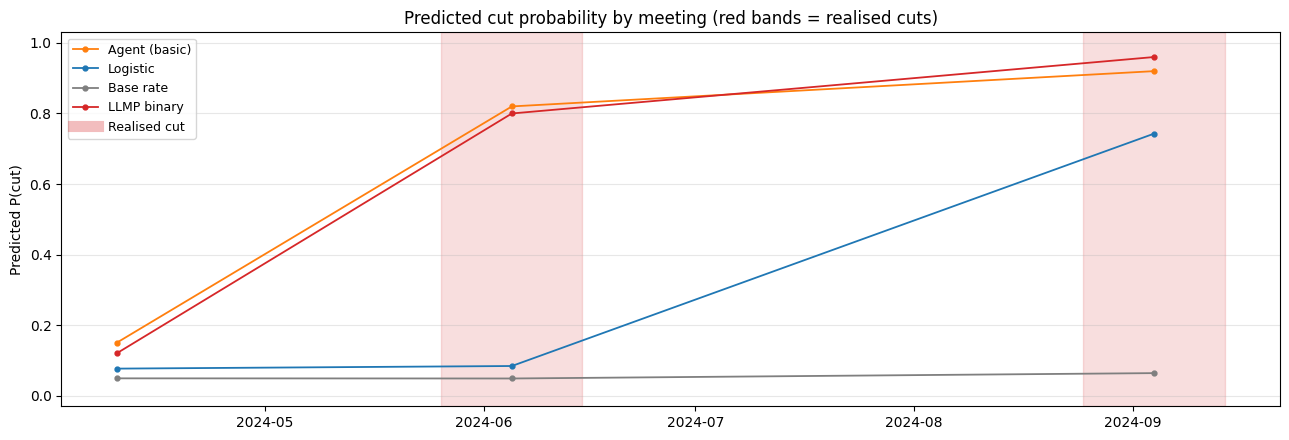

In [7]:
fig, _ = plot_decision_timeline(predictions_df, colors=PREDICTOR_COLORS, labels=PREDICTOR_LABELS)
plt.show()

---
## 7. Calibration (reliability curve)

The Brier score decomposes into calibration + refinement, and for decision
support calibration is the part that matters: when the predictor says 30%,
does a cut happen about 30% of the time? Points above the diagonal mean the
predictor under-predicts cuts in that bin; below means over-prediction.

With only ~120 meetings the bins are thin (marker size shows the count), so
read this as a coarse diagnostic, not a precise measurement. This section is
only meaningful under the `full` config — three smoke origins cannot
populate a reliability curve.

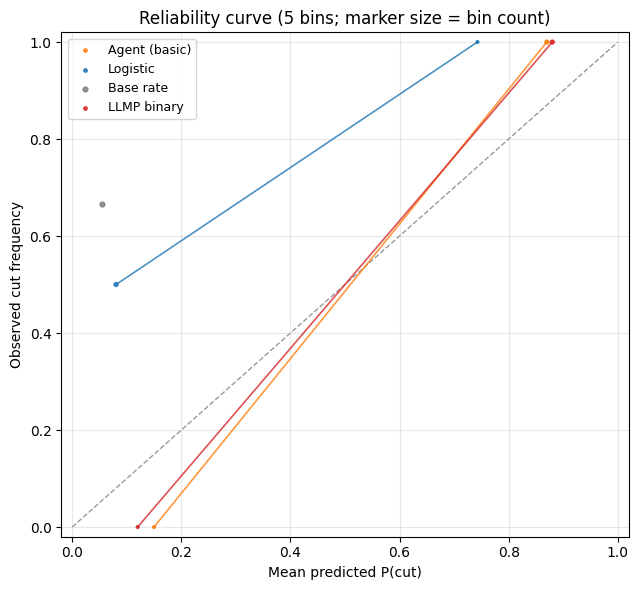

In [8]:
fig, _ = plot_reliability_curve(predictions_df, n_bins=5, colors=PREDICTOR_COLORS, labels=PREDICTOR_LABELS)
plt.show()

---
## 8. Inspecting agent reasoning

The agent's `DiscreteAgentForecastOutput` carries a `reasoning` trace and
`key_signals` alongside the probability, preserved in each prediction's
metadata. Two reasons to look at them:

1. **Debugging now** — a probability is a single number; the rationale tells
   you *why* the agent moved (or failed to move) off the base rate.
2. **Reasoning alignment later** — the Bank publishes its own rationale with
   every decision. The planned LLM evaluator will compare the agent's
   pre-decision reasoning against the Bank's published explanation, scoring
   whether the agent was right *for the right reasons*. These metadata
   fields are that evaluator's input.

In [9]:
rationales = rationales_table(results[agent.predictor_id])

for _, row in rationales.iterrows():
    outcome_row = predictions_df[
        (predictions_df["predictor_id"] == agent.predictor_id)
        & (predictions_df["meeting_date"] == row["meeting_date"])
    ]
    outcome = "CUT" if not outcome_row.empty and outcome_row["outcome"].iloc[0] == 1 else "no cut"
    print(f"Meeting {row['meeting_date'].date()}  —  P(cut) = {row['probability']:.2f}  (realised: {outcome})")
    if row.get("meta_key_signals") is not None:
        print(f"  signals: {row['meta_key_signals']}")
    if row.get("meta_reasoning") is not None:
        print(f"  reasoning: {str(row['meta_reasoning'])[:500]}")
    print()

Meeting 2024-04-10  —  P(cut) = 0.15  (realised: no cut)
  signals: ['CPI inflation gap (0.78% above target)', 'Yield spread (-0.77, pricing in future cuts)', 'Rising unemployment momentum', "Governing Council's cautious recent rhetoric regarding 'premature' cuts"]

Meeting 2024-06-05  —  P(cut) = 0.82  (realised: CUT)
  signals: ['Yield spread of -0.89% indicating strong market pricing for a cut', 'CPI inflation at 2.7%, well within the target control range', 'Unemployment momentum at 1.10, reflecting a cooling labor market', 'Successive downside surprises in core inflation measures over the spring of 2024']

Meeting 2024-09-04  —  P(cut) = 0.92  (realised: CUT)
  signals: ['Consecutive rate cuts in June and July 2024 establishing a downward trend', '2-year yield spread of -1.19% signaling strong market anticipation of easing', 'Rising unemployment momentum (1.2) indicating increased economic slack', 'CPI inflation gap at 0.53%, showing core price pressures are nearing the 2% target']

---
## 9. Protected eval (budget-gated)

`specs/boc_rate_cut_eval.yaml` covers the 12 announcements from January 2025
through June 2026: the tail of the easing cycle (cuts in Jan, Mar, Sep, Oct
2025) followed by an extended hold at 2.25%. This window is closer to — and
partly beyond — current model training cutoffs, making it the fairest
available comparison for the LLM-based predictors.

`max_runs: 5` is enforced through the `EvalTracker` (state in
`data/eval_runs.yaml`, gitignored). The scarcity is the point: an eval you
can re-run freely becomes another backtest to over-fit. Flip `RUN_PROTECTED_EVAL`
to `True` only when you have a predictor configuration you're confident in.

In [10]:
from aieng.forecasting.evaluation import EvalSpec, EvalTracker, evaluate


RUN_PROTECTED_EVAL = False  # each run spends budget; max_runs: 5 per tracker

if RUN_PROTECTED_EVAL:
    with (SPECS_DIR / "boc_rate_cut_eval.yaml").open() as f:
        eval_spec = EvalSpec.model_validate(yaml.safe_load(f))

    tracker = EvalTracker(ROOT / "data" / "eval_runs.yaml")
    print(f"Runs already spent: {tracker.runs_for(eval_spec.spec_id)}/{eval_spec.max_runs}\n")

    eval_results = {}
    for predictor in all_predictors:
        eval_results[predictor.predictor_id] = evaluate(
            predictor=predictor, spec=eval_spec, data_service=svc, tracker=tracker
        )
        r = eval_results[predictor.predictor_id]
        print(f"  {PREDICTOR_LABELS[predictor.predictor_id]:14s} mean Brier = {r.mean_score:.4f}  (run {r.run_number}/{eval_spec.max_runs})")

    eval_board = brier_leaderboard(eval_results, reference_id=base_rate.predictor_id)
    print()
    print(eval_board.to_string(index=False))
else:
    print("RUN_PROTECTED_EVAL = False — flip to True to spend an eval run.")

RUN_PROTECTED_EVAL = False — flip to True to spend an eval run.


---
## 10. What's next — the deferred components

This notebook completes the **quantitative** version of the problem. Three
components are deliberately deferred, and the code leaves explicit seams for
each:

1. **BoC communications as context.** Every decision comes with a press
   release, and four per year come with a full Monetary Policy Report. The
   `BinaryProbabilityLLMPredictorConfig.user_prompt_suffix` hook and the
   `build_boc_news_config` retrieval sub-agent are the insertion points for
   report-grounded variants once the document ingestion work (Track 2)
   lands. The key engineering constraint carries over unchanged: documents
   must be filtered by `released_at`, exactly like series data.

2. **Reasoning-alignment evaluation.** The agent already emits `reasoning`
   and `key_signals` per meeting (section 8). An LLM evaluator comparing
   that rationale against the Bank's own published explanation would
   complement the Brier score with a *process* metric — was the predictor
   right for the right reasons? This matters most precisely where the Brier
   score is least trustworthy (historical origins with leakage).

3. **Live forecasting.** The cleanest evaluation needs no leakage analysis
   at all: forecast the *next* announcement before it happens. The eval spec
   ends at June 2026; extending `meeting_schedule.yaml` with the Bank's
   published 2027 calendar and issuing forecasts the day before each
   announcement turns this use case into a standing live experiment — eight
   genuinely out-of-sample data points per year.